# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE
print(os.getcwd())
print(os.listdir("."))

# 2. Acquire and load your primary dataset
# YOUR CODE HERE
swiid_url = "https://raw.githubusercontent.com/fsolt/swiid/master/data/swiid_summary.csv"
swiid_raw = pd.read_csv(swiid_url)
output_folder = "../../../data/hw/hw_3"

/Users/schwertpunkt/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
['hw_3_Ryu_Hasegawa.ipynb']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
swiid_raw.info()
swiid_raw.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6628 entries, 0 to 6627
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       6628 non-null   object 
 1   year          6628 non-null   int64  
 2   gini_disp     6628 non-null   float64
 3   gini_disp_se  6628 non-null   float64
 4   gini_mkt      6628 non-null   float64
 5   gini_mkt_se   6628 non-null   float64
 6   abs_red       2756 non-null   float64
 7   abs_red_se    2756 non-null   float64
 8   rel_red       2756 non-null   float64
 9   rel_red_se    2756 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 517.9+ KB


,country,year,gini_disp,gini_disp_se,gini_mkt,gini_mkt_se,abs_red,abs_red_se,rel_red,rel_red_se
0,Afghanistan,2007,31.4,2.48,32.7,2.72,NaN,NaN,NaN,NaN
1,Afghanistan,2008,31.4,2.40,32.8,2.65,NaN,NaN,NaN,NaN


In [3]:
# 2. Rename columns and select a clean subset
swiid_column_map = {
    "country": "country",
    "year": "year",
    "gini_mkt": "gini_market",
    "gini_disp": "gini_disposable"
}

swiid_clean = swiid_raw[list(swiid_column_map.keys())].rename(columns=swiid_column_map)

country_name_map = {
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Viet Nam": "Vietnam",
    "Czech Republic": "Czechia",
    "Slovak Republic": "Slovakia",
    "Republic of Korea": "South Korea",
    "Korea, Republic of": "South Korea",
    "Türkiye": "Turkey"
}

swiid_clean["country"] = swiid_clean["country"].replace(country_name_map)
swiid_clean.head(2)


,country,year,gini_market,gini_disposable
0,Afghanistan,2007,32.7,31.4
1,Afghanistan,2008,32.8,31.4


In [4]:
# 3. Filter row or column filters if necessary
swiid_filtered = swiid_clean.query("year >= 2000 and year >= 2022").copy()

swiid_filtered["abs_redist"] = swiid_filtered["gini_market"] - swiid_filtered["gini_disposable"]
swiid_filtered["rel_redist"] = (swiid_filtered["abs_redist"] / swiid_filtered["gini_market"]) * 100

In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
swiid_filtered.info()

swiid_analysis = swiid_filtered.dropna(subset=[
    "country",
    "year",
    "gini_market",
    "gini_disposable",
    "abs_redist",
    "rel_redist"
]).copy()

swiid_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 37 to 6602
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          222 non-null    object 
 1   year             222 non-null    int64  
 2   gini_market      222 non-null    float64
 3   gini_disposable  222 non-null    float64
 4   abs_redist       222 non-null    float64
 5   rel_redist       222 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 12.1+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 37 to 6602
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          222 non-null    object 
 1   year             222 non-null    int64  
 2   gini_market      222 non-null    float64
 3   gini_disposable  222 non-null    float64
 4   abs_redist       222 non-null    float64
 5   rel_redist       222 non-null    float64

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
vdem_url = "https://ourworldindata.org/grapher/electoral-democracy-index.csv"
vdem_raw = pd.read_csv(vdem_url)
vdem_raw.head(2)

,Entity,Code,Year,Electoral democracy index,World region according to OWID
0,Afghanistan,AFG,1789,0.019,Asia
1,Afghanistan,AFG,1790,0.019,Asia


In [7]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
vdem_column_map = {
    "Entity": "country",
    "Code": "country_code",
    "Year": "year",
    "Electoral democracy index": "e_dem"
}

vdem_clean = vdem_raw.rename(columns=vdem_column_map)
vdem_clean = vdem_clean[["country", "country_code", "year", "e_dem"]].copy()
vdem_clean["country"] = vdem_clean["country"].replace(country_name_map)
vdem_clean = vdem_clean.dropna(subset=["country", "year", "e_dem"])

vdem_file = f"{output_folder}/vdem_cleaned.csv"
vdem_clean.to_csv(vdem_file, index=False)

vdem_clean.head(2)

merged_df = pd.merge(swiid_analysis, vdem_clean, on=["country", "year"])

print(len (merged_df))
merged_file = f"{output_folder}/redistribution_democracy_merged.csv"

merged_df.head(5)

210


,country,year,gini_market,gini_disposable,abs_redist,rel_redist,country_code,e_dem
0,Albania,2022,50.8,34.7,16.1,31.692913,ALB,0.517
1,Argentina,2022,39.8,37.9,1.9,4.773869,ARG,0.831
2,Argentina,2023,39.9,38.1,1.8,4.511278,ARG,0.838
3,Argentina,2024,40.0,38.4,1.6,4.000000,ARG,0.721
4,Armenia,2022,45.3,33.9,11.4,25.165563,ARM,0.654


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
  - The merge key is country and year
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.
  - The number of matching rows are 210

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
democracy_bins = [0, 0.33, 0.66, 1]
democracy_labels =["low", "medium", "high"]

merged_df["democracy"] = pd.cut(merged_df["e_dem"], bins=democracy_bins, labels=democracy_labels)

group_means = merged_df.groupby("democracy")[["rel_redist", "abs_redist", "gini_market", "gini_disposable"]].mean().reset_index()
group_counts = merged_df.groupby("democracy")["country"].count().reset_index()
group_counts = group_counts.rename(columns={"country": "observations"})

group_summary = pd.merge(group_means, group_counts, on="democracy")
group_summary

/var/folders/b5/dnd2l5zj25x4ppn9wj5v09b40000gn/T/ipykernel_28894/1648937904.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged_df.groupby("democracy")[["rel_redist", "abs_redist", "gini_market", "gini_disposable"]].mean().reset_index()
/var/folders/b5/dnd2l5zj25x4ppn9wj5v09b40000gn/T/ipykernel_28894/1648937904.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = merged_df.groupby("democracy")["country"].count().reset_index()


,democracy,rel_redist,abs_redist,gini_market,gini_disposable,observations
0,low,9.923415,3.939130,40.154348,36.215217,46
1,medium,10.374995,4.885484,42.906452,38.020968,62
2,high,28.764113,13.853922,47.853922,34.000000,102


- *Extra Credit: Write your economic or policy related interpretation here*

The results show that countries with high electoral democracy have much higher average redistribution than countries with low or medium electoral democracy. One possible interpretation is that democratic governments face stronger pressure from voters to reduce inequality through taxes and transfers. The high democracy group starts with relatively high market inequality, but disposable inequality becomes much lower after redistribution. This suggests that redistribution plays an important role in shaping final income inequality.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

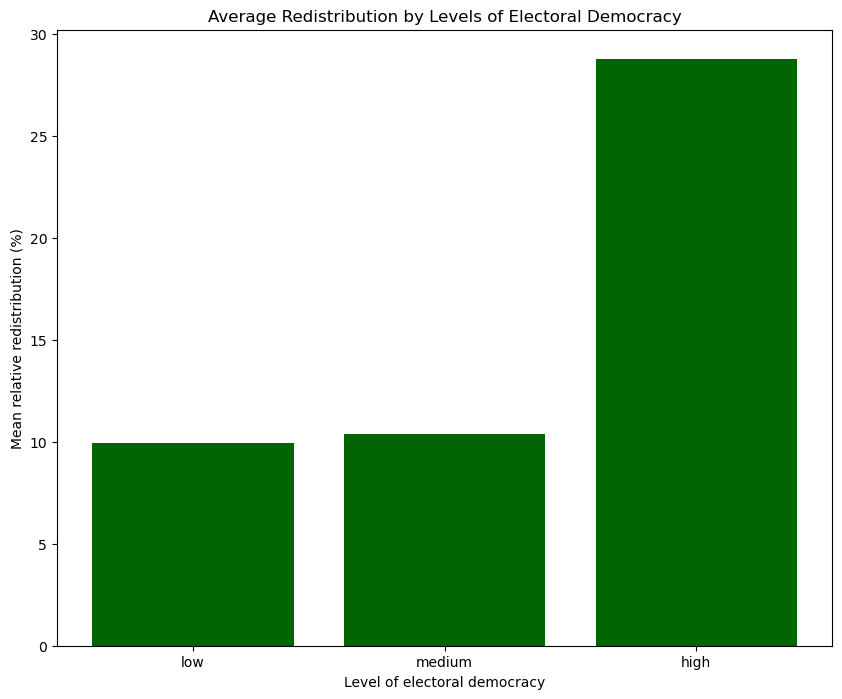

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
plt.figure(figsize=(10,8))
plt.bar(group_summary["democracy"].astype(str), group_summary["rel_redist"], color="darkgreen")

plt.title("Average Redistribution by Levels of Electoral Democracy")
plt.xlabel("Level of electoral democracy")
plt.ylabel("Mean relative redistribution (%)")
plt.grid(False)
plt.show()

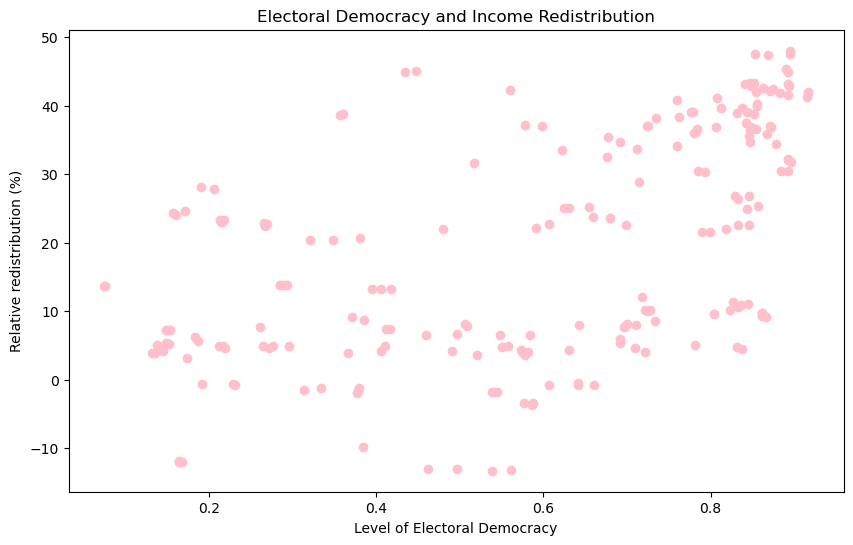

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
plot_df = merged_df.dropna(subset=["e_dem", "rel_redist"]).copy()

plt.figure(figsize=(10,6))
plt.scatter(x=plot_df["e_dem"], y=plot_df["rel_redist"], color="pink", marker="o")

plt.title("Electoral Democracy and Income Redistribution")
plt.xlabel("Level of Electoral Democracy")
plt.ylabel("Relative redistribution (%)")
plt.grid(False)
plt.show()

                            OLS Regression Results                            
Dep. Variable:             rel_redist   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     88.89
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           8.48e-18
Time:                        15:15:53   Log-Likelihood:                -848.53
No. Observations:                 210   AIC:                             1701.
Df Residuals:                     208   BIC:                             1708.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7010      2.414     -0.705      0.4

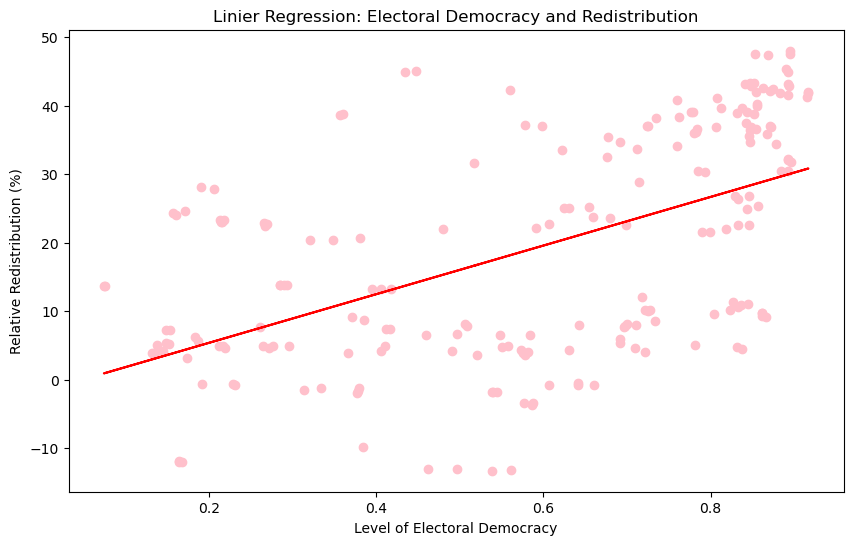

In [11]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import statsmodels.api as sm

# Fit a simple linear regression and overlay the line of best fit
regression_df = merged_df.dropna(subset=["e_dem", "rel_redist"]).copy()

X = regression_df["e_dem"]
y = regression_df["rel_redist"]
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())

b0, b1 = model.params.iloc[0], model.params.iloc[1]

plt.figure(figsize=(10, 6))
plt.scatter(regression_df["e_dem"], regression_df["rel_redist"], color="pink", marker="o")
plt.plot(regression_df["e_dem"], b0 + b1 * regression_df["e_dem"], color="red")

plt.title("Linier Regression: Electoral Democracy and Redistribution")
plt.xlabel("Level of Electoral Democracy")
plt.ylabel("Relative Redistribution (%)")
plt.grid(False)
plt.show()


- *Extra Credit: Write your visualization and regression interpretations here*

The regression suggests that electoral democracy is positively associated with relative redistribution. The coefficient on electoral democracy is about 35.49 and statistically significant. This means that more democratic countries tend to redistribute more income. The R-squared is about 0.30, so the model explains some, but not all, of the variation in redistribution

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.